Entries: 150000
Used detector gammas: 9831
Image max: 10.0
Nonzero pixels: 2444


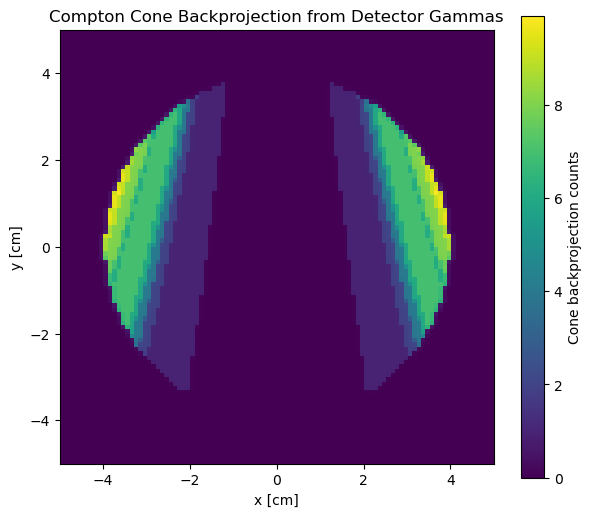

In [3]:
import ROOT
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# =========================
# USER SETTINGS
# =========================
root_file = "sucrose.root"
tree_name = "t"

detector_vlms = [4]

E0 = 662.0        # incident gamma energy in keV
me = 511.0        # electron rest mass energy in keV

source_pos = np.array([0.0, 20.0, 0.0])  # source position [cm]

xmin, xmax = -5.0, 5.0
ymin, ymax = -5.0, 5.0
z_slice = 0.0

nx, ny = 100, 100
angle_tolerance = 0.02   # radians; increase to 0.08 if too sparse
max_detector_gammas = 1000

# =========================
# OPEN ROOT FILE
# =========================
f = ROOT.TFile.Open(root_file)
if not f or f.IsZombie():
    raise RuntimeError("Could not open ROOT file")

t = f.Get(tree_name)
if not t:
    raise RuntimeError("Could not find tree")

print("Entries:", t.GetEntries())

# =========================
# IMAGE GRID
# =========================
xs = np.linspace(xmin, xmax, nx)
ys = np.linspace(ymin, ymax, ny)

image = np.zeros((ny, nx))

used_detector_gammas = 0

# =========================
# CONE BACKPROJECTION LOOP
# =========================
for entry in t:

    n = min(
        len(entry.pdg),
        len(entry.vlm),
        len(entry.x),
        len(entry.y),
        len(entry.z),
        len(entry.et)
    )

    for i in range(n):

        # only gammas
        if int(entry.pdg[i]) != 22:
            continue

        # only gammas recorded in detector volumes
        if int(entry.vlm[i]) not in detector_vlms:
            continue

        # scattered gamma energy recorded at detector
        Es = float(entry.et[i])

        if Es <= 0 or Es >= E0:
            continue

        # Compton formula:
        # cos(theta) = 1 - me * (1/Es - 1/E0)
        cos_theta = 1.0 - me * (1.0 / Es - 1.0 / E0)

        if cos_theta < -1.0 or cos_theta > 1.0:
            continue

        theta = math.acos(cos_theta)

        detector_pos = np.array([
            float(entry.x[i]),
            float(entry.y[i]),
            float(entry.z[i])
        ])

        # =========================
        # BACKPROJECT CONE INTO X-Y IMAGE
        # =========================
        for iy, y in enumerate(ys):
            for ix, x in enumerate(xs):

                voxel = np.array([x, y, z_slice])
                phantom_radius = 4.0
                if x*x + y*y > phantom_radius*phantom_radius:
                    continue

                # incoming direction: source -> voxel
                u_in = voxel - source_pos

                # outgoing direction: voxel -> detector
                u_out = detector_pos - voxel

                norm_in = np.linalg.norm(u_in)
                norm_out = np.linalg.norm(u_out)

                if norm_in == 0 or norm_out == 0:
                    continue

                u_in = u_in / norm_in
                u_out = u_out / norm_out

                # angle between incoming and outgoing directions
                alpha = math.acos(np.clip(np.dot(u_in, u_out), -1.0, 1.0))

                # if voxel lies on the Compton cone, add count
                if abs(alpha - theta) < angle_tolerance:
                    image[iy, ix] += 1.0

        used_detector_gammas += 1

print("Used detector gammas:", used_detector_gammas)
print("Image max:", image.max())
print("Nonzero pixels:", np.count_nonzero(image))

# =========================
# SMOOTH AND PLOT
# =========================
image_smooth = gaussian_filter(image, sigma=0.4)

plt.figure(figsize=(7, 6))
plt.imshow(
    image_smooth,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    aspect="equal",
    vmin=0
)
plt.colorbar(label="Cone backprojection counts")
plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.title("Compton Cone Backprojection from Detector Gammas")
plt.show()